In [27]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import joblib

ROOT_DIR = Path.cwd().parent

sys.path.insert(0, str(ROOT_DIR))

PROCESSED_DIR = ROOT_DIR / "data" / "processed"
MODEL_DIR = ROOT_DIR / "models"

print("Project:", ROOT_DIR)

Project: c:\Users\SHUBHAM\OneDrive\Desktop\AlphaTrade


In [28]:
def backtest_stock(ticker):

    print("\n" + "=" * 60)
    print(f"Backtesting {ticker}")
    print("=" * 60)

    data_file = (
        PROCESSED_DIR /
        f"{ticker}_features.csv"
    )

    model_file = (
        MODEL_DIR /
        f"{ticker}_model.pkl"
    )

    feature_file = (
        MODEL_DIR /
        f"{ticker}_feature_columns.pkl"
    )

    if not data_file.exists():
        print(f"❌ Data not found: {data_file}")
        return None

    if not model_file.exists():
        print(f"❌ Model not found: {model_file}")
        return None

    # Load
    df = pd.read_csv(data_file)

    model = joblib.load(model_file)

    feature_columns = joblib.load(
        feature_file
    )

    # Prediction
    df["Predicted_Price"] = model.predict(
        df[feature_columns]
    )

    # Expected return
    df["Expected_Return"] = (
        (
            df["Predicted_Price"]
            - df["Close"]
        )
        / df["Close"]
    )

    # Signal
    df["Signal"] = "HOLD"

    df.loc[
        df["Expected_Return"] >= 0.02,
        "Signal"
    ] = "BUY"

    df.loc[
        df["Expected_Return"] <= -0.02,
        "Signal"
    ] = "SELL"

    # Actual next-day return
    df["Actual_Return"] = (
        df["Target"] / df["Close"]
    ) - 1

    # Strategy return
    df["Strategy_Return"] = 0.0

    df.loc[
        df["Signal"] == "BUY",
        "Strategy_Return"
    ] = df["Actual_Return"]

    df.loc[
        df["Signal"] == "SELL",
        "Strategy_Return"
    ] = -df["Actual_Return"]

    # Cumulative returns
    df["Cumulative_Strategy"] = (
        1 + df["Strategy_Return"]
    ).cumprod()

    df["Cumulative_Buy_Hold"] = (
        1 + df["Actual_Return"]
    ).cumprod()

    # Metrics
    strategy_return = (
        df["Cumulative_Strategy"].iloc[-1]
        - 1
    ) * 100

    buy_hold_return = (
        df["Cumulative_Buy_Hold"].iloc[-1]
        - 1
    ) * 100

    max_drawdown = (
        (
            df["Cumulative_Strategy"]
            / df["Cumulative_Strategy"].cummax()
        ) - 1
    ).min() * 100

    total_trades = (
        df["Signal"]
        .isin(["BUY", "SELL"])
        .sum()
    )

    print(
        f"Strategy Return : {strategy_return:.2f}%"
    )

    print(
        f"Buy & Hold     : {buy_hold_return:.2f}%"
    )

    print(
        f"Max Drawdown   : {max_drawdown:.2f}%"
    )

    print(
        f"Total Trades   : {total_trades}"
    )

    # Save results
    output_file = (
        PROCESSED_DIR /
        f"{ticker}_backtest_results.csv"
    )

    df.to_csv(
        output_file,
        index=False
    )

    print(
        f"✅ Saved: {output_file}"
    )

    return {
        "Ticker": ticker,
        "Strategy Return (%)": strategy_return,
        "Buy & Hold (%)": buy_hold_return,
        "Max Drawdown (%)": max_drawdown,
        "Total Trades": total_trades
    }

In [29]:
result = backtest_stock("AAPL")

result


Backtesting AAPL
Strategy Return : 60671.66%
Buy & Hold     : 879.37%
Max Drawdown   : -44.76%
Total Trades   : 676
✅ Saved: c:\Users\SHUBHAM\OneDrive\Desktop\AlphaTrade\data\processed\AAPL_backtest_results.csv


{'Ticker': 'AAPL',
 'Strategy Return (%)': np.float64(60671.65931565618),
 'Buy & Hold (%)': np.float64(879.3677475718683),
 'Max Drawdown (%)': np.float64(-44.76196790678289),
 'Total Trades': np.int64(676)}

In [30]:
TICKERS = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "TSLA",
    "NVDA"
]

backtest_results = []

for ticker in TICKERS:

    result = backtest_stock(
        ticker
    )

    if result is not None:
        backtest_results.append(
            result
        )


Backtesting AAPL
Strategy Return : 60671.66%
Buy & Hold     : 879.37%
Max Drawdown   : -44.76%
Total Trades   : 676
✅ Saved: c:\Users\SHUBHAM\OneDrive\Desktop\AlphaTrade\data\processed\AAPL_backtest_results.csv

Backtesting MSFT
Strategy Return : 39972.69%
Buy & Hold     : 1092.01%
Max Drawdown   : -26.34%
Total Trades   : 472
✅ Saved: c:\Users\SHUBHAM\OneDrive\Desktop\AlphaTrade\data\processed\MSFT_backtest_results.csv

Backtesting GOOGL
Strategy Return : 45680.50%
Buy & Hold     : 1131.75%
Max Drawdown   : -62.02%
Total Trades   : 655
✅ Saved: c:\Users\SHUBHAM\OneDrive\Desktop\AlphaTrade\data\processed\GOOGL_backtest_results.csv

Backtesting AMZN
Strategy Return : 969064.04%
Buy & Hold     : 1306.99%
Max Drawdown   : -42.32%
Total Trades   : 662
✅ Saved: c:\Users\SHUBHAM\OneDrive\Desktop\AlphaTrade\data\processed\AMZN_backtest_results.csv

Backtesting TSLA
Strategy Return : 1747116546202121.50%
Buy & Hold     : 2523.43%
Max Drawdown   : -46.41%
Total Trades   : 891
✅ Saved: c:\Users

In [31]:
backtest_df = pd.DataFrame(
    backtest_results
)

backtest_df

,Ticker,Strategy Return (%),Buy & Hold (%),Max Drawdown (%),Total Trades
0,AAPL,6.067166e+04,879.367748,-44.761968,676
1,MSFT,3.997269e+04,1092.011495,-26.340120,472
2,GOOGL,4.568050e+04,1131.749822,-62.015694,655
3,AMZN,9.690640e+05,1306.990761,-42.319299,662
4,TSLA,1.747117e+15,2523.428546,-46.405886,891
5,NVDA,5.244186e+11,39109.405380,-76.283070,1055


In [32]:
summary_file = (
    PROCESSED_DIR /
    "backtest_summary.csv"
)

backtest_df.to_csv(
    summary_file,
    index=False
)

print(
    f"✅ Summary saved: {summary_file}"
)

✅ Summary saved: c:\Users\SHUBHAM\OneDrive\Desktop\AlphaTrade\data\processed\backtest_summary.csv


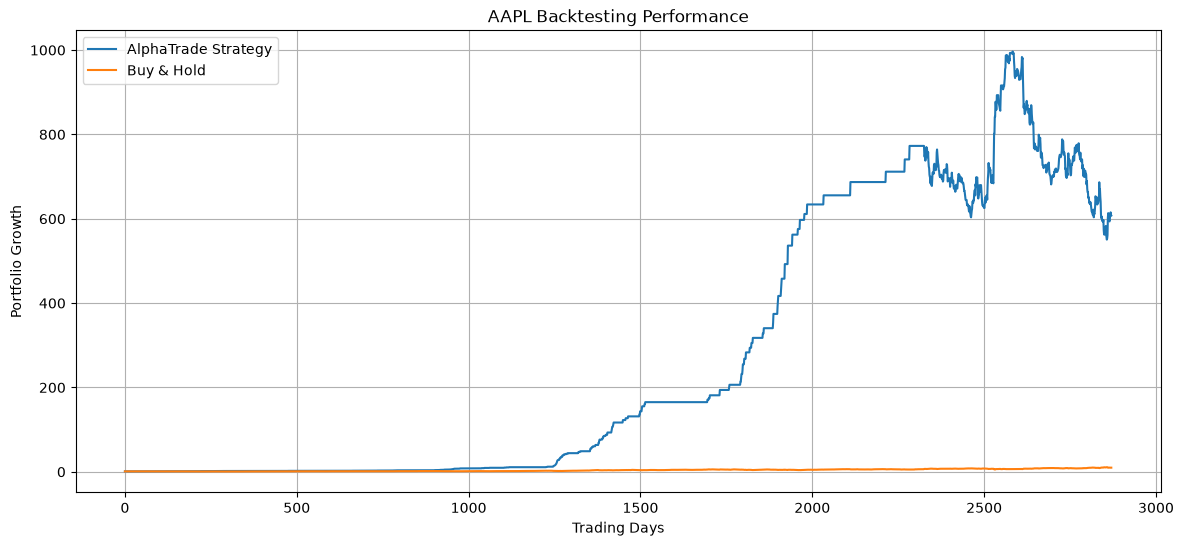

In [33]:
import matplotlib.pyplot as plt

ticker = "AAPL"

file_path = (
    PROCESSED_DIR /
    f"{ticker}_backtest_results.csv"
)

df = pd.read_csv(file_path)

plt.figure(figsize=(14, 6))

plt.plot(
    df["Cumulative_Strategy"],
    label="AlphaTrade Strategy"
)

plt.plot(
    df["Cumulative_Buy_Hold"],
    label="Buy & Hold"
)

plt.title(
    f"{ticker} Backtesting Performance"
)

plt.xlabel("Trading Days")

plt.ylabel("Portfolio Growth")

plt.legend()

plt.grid(True)

plt.show()